### Real Options Black Scholes for R&D in Pharma

Fetching market data for volatility proxy calculation: ['VRTX', 'BIIB', 'INCY']...
Calculated localized sector proxy volatility: 0.3250 (32.50%)

--- BASELINE VALUATION RESULTS ---
Real_Option_Value: $297,125,269.67
d1: 2.0528
d2_Prob_Success: 0.9258
Delta: 0.9800


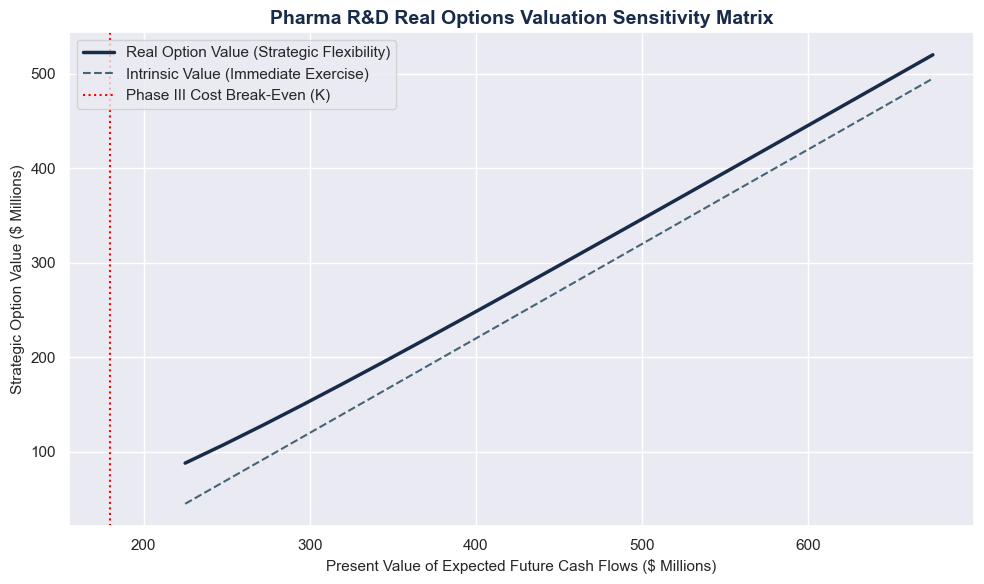

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

class PharmaRealOptionsPricer:
    def __init__(self, asset_value, strike_cost, time_to_decision, risk_free_rate, volatility=None):
        """
        Initializes the Real Options Valuation Framework.
        S = asset_value (PV of future cash flows)
        K = strike_cost (Phase III trial & deployment costs)
        t = time_to_decision (Time to maturity in years)
        r = risk_free_rate (Continuous risk-free rate)
        sigma = volatility (Annualized asset volatility)
        """
        self.S = float(asset_value)
        self.K = float(strike_cost)
        self.t = float(time_to_decision)
        self.r = float(risk_free_rate)
        self.sigma = float(volatility) if volatility is not None else None

    def fetch_industry_volatility(self, ticker_list, period="2y"):
        """
        Ingests real-world financial data from a basket of peer biotech/pharma 
        companies to compute an annualized proxy historical volatility.
        """
        print(f"Fetching market data for volatility proxy calculation: {ticker_list}...")
        try:
            data = yf.download(ticker_list, period=period, progress=False)['Close']
            # Calculate daily log returns
            log_returns = np.log(data / data.shift(1))
            # Calculate standard deviation of daily returns and annualize it (252 trading days)
            daily_std = log_returns.std()
            annualized_vols = daily_std * np.sqrt(252)
            
            # Use the mean volatility of the sector proxy basket
            self.sigma = float(annualized_vols.mean())
            print(f"Calculated localized sector proxy volatility: {self.sigma:.4f} ({self.sigma*100:.2f}%)")
            return self.sigma
        except Exception as e:
            raise RuntimeError(f"Failed to fetch market data via yfinance: {e}")

    def calculate_option_value(self):
        """
        Executes the continuous analytical Black-Scholes-Merton valuation.
        """
        if self.sigma is None:
            raise ValueError("Volatility (sigma) must be calculated or provided before valuation.")
            
        # Edge case handling for zero time or immediate expiration
        if self.t <= 0:
            return max(self.S - self.K, 0.0)

        # Calculate d1 and d2 parameters
        d1 = (np.log(self.S / self.K) + (self.r + (self.sigma ** 2) / 2.0) * self.t) / (self.sigma * np.sqrt(self.t))
        d2 = d1 - self.sigma * np.sqrt(self.t)

        # Continuous analytical option price calculation
        option_value = self.S * stats.norm.cdf(d1) - self.K * np.exp(-self.r * self.t) * stats.norm.cdf(d2)
        
        metrics = {
            "Real_Option_Value": option_value,
            "d1": d1,
            "d2_Prob_Success": stats.norm.cdf(d2), # Risk-neutral prob of execution
            "Delta": stats.norm.cdf(d1)            # Sensitivity of option to asset value moves
        }
        return metrics

    def generate_sensitivity_matrix(self, s_min=0.5, s_max=1.5, steps=20):
        """
        Performs a parametric sweep over varying asset present values 
        to model decision boundaries (Exercise vs. Defer vs. Abandon).
        """
        s_range = np.linspace(self.S * s_min, self.S * s_max, steps)
        results = []
        
        # Preserve core asset value state
        original_S = self.S
        
        for s in s_range:
            self.S = s
            res = self.calculate_option_value()
            results.append({
                "Asset_Value": s,
                "Option_Value": res["Real_Option_Value"],
                "Delta": res["Delta"]
            })
            
        self.S = original_S # Reset state
        return pd.DataFrame(results)

# ==========================================
# Execution / Implementation Block
# ==========================================
if __name__ == "__main__":
    # Base parameters for a Phase II oncology pipeline asset
    PROJECTED_COMMERCIAL_VALUE = 450_000_000  # S: $450M PV
    PHASE_III_LAUNCH_CAPEX = 180_000_000      # K: $180M trial/launch cost
    DECISION_WINDOW_YEARS = 3.5               # t: 3.5 years left on key patent path
    MACRO_RISK_FREE_RATE = 0.042              # r: 4.2% Treasury Yield Baseline

    # 1. Instantiate the quantitative asset framework
    pricer = PharmaRealOptionsPricer(
        asset_value=PROJECTED_COMMERCIAL_VALUE,
        strike_cost=PHASE_III_LAUNCH_CAPEX,
        time_to_decision=DECISION_WINDOW_YEARS,
        risk_free_rate=MACRO_RISK_FREE_RATE
    )

    # 2. Derive volatility dynamically using a Mid-Cap Biotech basket proxy
    # Examples: VRTX, BIIB, REGN, INCY
    biotech_proxies = ["VRTX", "BIIB", "INCY"]
    pricer.fetch_industry_volatility(ticker_list=biotech_proxies)

    # 3. Calculate baseline pricing metrics
    valuation_results = pricer.calculate_option_value()
    print("\n--- BASELINE VALUATION RESULTS ---")
    for key, val in valuation_results.items():
        print(f"{key}: {val:,.4f}" if "Value" not in key else f"{key}: ${val:,.2f}")

    # 4. Parametric sweep for sensitivity modeling
    sensitivity_df = pricer.generate_sensitivity_matrix()

    # 5. Data Visualization Layer
    sns.set_theme(style="darkgrid")
    plt.figure(figsize=(10, 6))
    plt.plot(sensitivity_df["Asset_Value"] / 1e6, sensitivity_df["Option_Value"] / 1e6, 
             label="Real Option Value (Strategic Flexibility)", color="#182B49", linewidth=2.5)
    plt.plot(sensitivity_df["Asset_Value"] / 1e6, 
             np.maximum((sensitivity_df["Asset_Value"] - PHASE_III_LAUNCH_CAPEX) / 1e6, 0), 
             label="Intrinsic Value (Immediate Exercise)", color="#466478", linestyle="--")
    
    plt.title("Pharma R&D Real Options Valuation Sensitivity Matrix", fontsize=14, fontweight='bold', color='#182B49')
    plt.xlabel("Present Value of Expected Future Cash Flows ($ Millions)", fontsize=11)
    plt.ylabel("Strategic Option Value ($ Millions)", fontsize=11)
    plt.axvline(x=PHASE_III_LAUNCH_CAPEX / 1e6, color='red', linestyle=':', label='Phase III Cost Break-Even (K)')
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

Fetching market data for volatility proxy calculation: ['VRTX', 'BIIB', 'INCY']...
Calculated localized sector proxy volatility: 0.3250 (32.50%)

--- 2D SENSITIVITY MATRIX (Option Value in $ Millions) ---
             225.0         265.9         306.8         347.7         388.6  \
20.0  7.549098e+07  1.130609e+08  1.525245e+08  1.928134e+08  2.334553e+08   
25.5  8.056361e+07  1.166819e+08  1.549330e+08  1.943581e+08  2.344291e+08   
30.9  8.629764e+07  1.214214e+08  1.586529e+08  1.971951e+08  2.365593e+08   
36.4  9.238416e+07  1.268808e+08  1.633562e+08  2.011535e+08  2.398461e+08   
41.8  9.864360e+07  1.327831e+08  1.687408e+08  2.059694e+08  2.441021e+08   
47.3  1.049643e+08  1.389417e+08  1.745742e+08  2.113999e+08  2.491026e+08   
52.7  1.112718e+08  1.452282e+08  1.806856e+08  2.172487e+08  2.546437e+08   
58.2  1.175139e+08  1.515515e+08  1.869487e+08  2.233634e+08  2.605568e+08   
63.6  1.236518e+08  1.578450e+08  1.932694e+08  2.296265e+08  2.667066e+08   
69.1  1.296560e

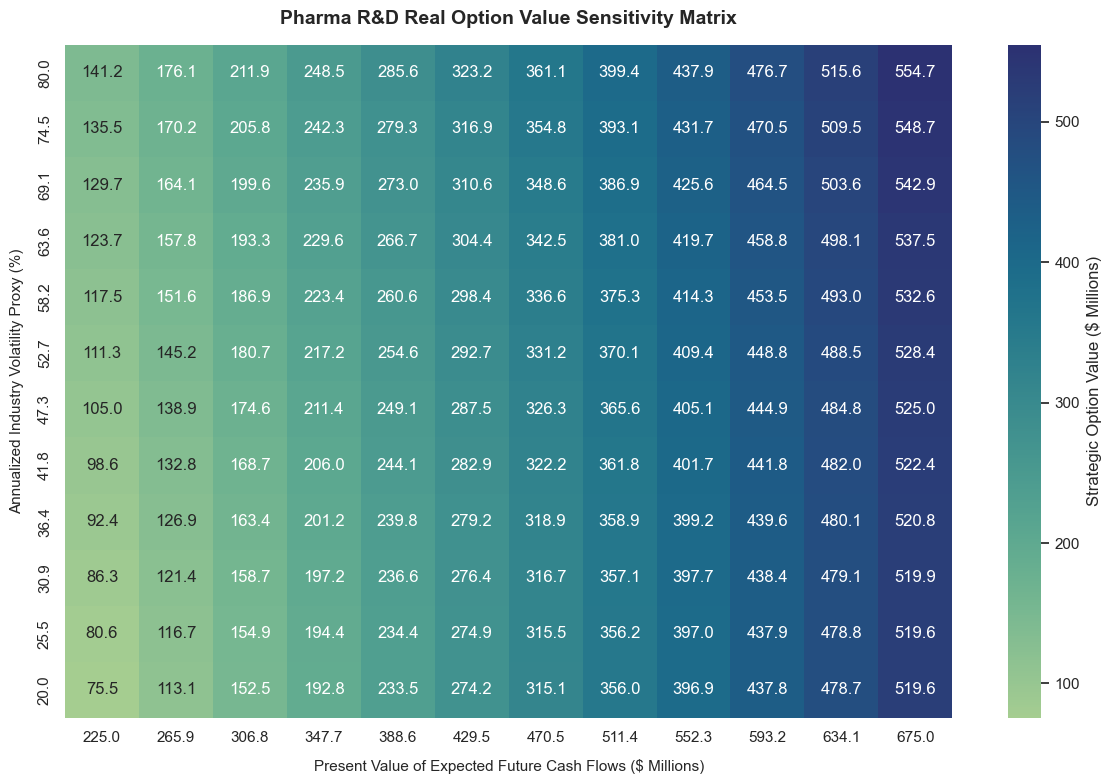

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

class PharmaRealOptionsPricer:
    def __init__(self, asset_value, strike_cost, time_to_decision, risk_free_rate, volatility=None):

        self.S = float(asset_value)
        self.K = float(strike_cost)
        self.t = float(time_to_decision)
        self.r = float(risk_free_rate)
        self.sigma = float(volatility) if volatility is not None else None

    def fetch_industry_volatility(self, ticker_list, period="2y"):
       
        print(f"Fetching market data for volatility proxy calculation: {ticker_list}...")
        try:
            # Handle multi-ticker structure safely
            data = yf.download(ticker_list, period=period, progress=False)
            if isinstance(data.columns, pd.MultiIndex):
                close_data = data['Close']
            else:
                close_data = data['Close']
                
            # Calculate daily log returns
            log_returns = np.log(close_data / close_data.shift(1))
            # Calculate standard deviation of daily returns and annualize it (252 trading days)
            daily_std = log_returns.std()
            annualized_vols = daily_std * np.sqrt(252)
            
            # Use the mean volatility of the sector proxy basket
            self.sigma = float(annualized_vols.mean())
            print(f"Calculated localized sector proxy volatility: {self.sigma:.4f} ({self.sigma*100:.2f}%)")
            return self.sigma
        except Exception as e:
            raise RuntimeError(f"Failed to fetch market data via yfinance: {e}")

    def calculate_option_value(self):
  
        if self.sigma is None:
            raise ValueError("Volatility (sigma) must be calculated or provided before valuation.")
            
        if self.t <= 0:
            return max(self.S - self.K, 0.0)

        # Calculate d1 and d2 parameters
        d1 = (np.log(self.S / self.K) + (self.r + (self.sigma ** 2) / 2.0) * self.t) / (self.sigma * np.sqrt(self.t))
        d2 = d1 - self.sigma * np.sqrt(self.t)

        # Continuous analytical option price calculation
        option_value = self.S * stats.norm.cdf(d1) - self.K * np.exp(-self.r * self.t) * stats.norm.cdf(d2)
        
        metrics = {
            "Real_Option_Value": option_value,
            "d1": d1,
            "d2_Prob_Success": stats.norm.cdf(d2), 
            "Delta": stats.norm.cdf(d1)            
        }
        return metrics

    def generate_sensitivity_matrix(self, s_min=0.5, s_max=1.5, vol_min=0.2, vol_max=0.8, steps=15):

        s_range = np.linspace(self.S * s_min, self.S * s_max, steps)
        vol_range = np.linspace(vol_min, vol_max, steps)
        
        # Save state
        original_S = self.S
        original_sigma = self.sigma
        
        # Create an empty matrix/grid structure
        matrix_data = np.zeros((steps, steps))
        
        for i, vol in enumerate(vol_range):
            for j, s in enumerate(s_range):
                self.S = s
                self.sigma = vol
                res = self.calculate_option_value()
                matrix_data[i, j] = res["Real_Option_Value"]
                
        # Revert state
        self.S = original_S
        self.sigma = original_sigma
        
        # Format as a clean DataFrame for matrix viewing & heatmapping
        df = pd.DataFrame(
            matrix_data, 
            index=np.round(vol_range * 100, 1), # Rows = Volatility %
            columns=np.round(s_range / 1e6, 1)  # Columns = Asset Value ($M)
        )
        return df

# ==========================================
# Execution / Implementation Block
# ==========================================
if __name__ == "__main__":
    PROJECTED_COMMERCIAL_VALUE = 450_000_000  # S: $450M PV
    PHASE_III_LAUNCH_CAPEX = 180_000_000      # K: $180M trial/launch cost
    DECISION_WINDOW_YEARS = 3.5               # t: 3.5 years
    MACRO_RISK_FREE_RATE = 0.042              # r: 4.2%

    pricer = PharmaRealOptionsPricer(
        asset_value=PROJECTED_COMMERCIAL_VALUE,
        strike_cost=PHASE_III_LAUNCH_CAPEX,
        time_to_decision=DECISION_WINDOW_YEARS,
        risk_free_rate=MACRO_RISK_FREE_RATE
    )

    biotech_proxies = ["VRTX", "BIIB", "INCY"]
    pricer.fetch_industry_volatility(ticker_list=biotech_proxies)

    # Generate the TRUE 2D Sensitivity Matrix
    # Sweeping Asset Value from 50% to 150% and Volatility from 20% to 80%
    matrix_df = pricer.generate_sensitivity_matrix(s_min=0.5, s_max=1.5, vol_min=0.2, vol_max=0.8, steps=12)
    
    print("\n--- 2D SENSITIVITY MATRIX (Option Value in $ Millions) ---")
    print(matrix_df.round(2))

    # 5. Visualizing the Matrix using a Heatmap
    plt.figure(figsize=(12, 8))
    
    # We divide the DataFrame values by 1e6 to present options values in Millions
    sns.heatmap(
        matrix_df / 1e6, 
        annot=True, 
        fmt=".1f", 
        cmap="crest", 
        cbar_kws={'label': 'Strategic Option Value ($ Millions)'}
    )
    
    plt.title("Pharma R&D Real Option Value Sensitivity Matrix", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Present Value of Expected Future Cash Flows ($ Millions)", fontsize=11, labelpad=10)
    plt.ylabel("Annualized Industry Volatility Proxy (%)", fontsize=11, labelpad=10)
    
    plt.gca().invert_yaxis() # Puts lowest volatility at the bottom
    plt.tight_layout()
    plt.show()